# Hyperparameter Tuning - Tuning hyperparameters in XGBoost using Grid Search

## This Notebook Covers
- Implementing grid search to evaluate multiple hyperparameters for XGBoost
- Using 3-fold CV validation for the model
- Concluding that hyperparameters tuned well on OOS data but performed poor than baseline on OOT data

## Libraries Used
- **Python:** pandas, numpy, matplotlib, sklearn, xgboost, json

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report, make_scorer
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('models/baseline_models.pkl', 'rb') as f:
    models_dict = pickle.load(f)

best_model_name = models_dict['best_model_name']
feature_cols = models_dict['feature_cols']

print(f"\nBest model based on previous analysis: {best_model_name}")
print(f"Features: {len(feature_cols)}")

with open('outputs/performance_summary.json', 'r') as f:
    baseline_performance = json.load(f)

print(f"\nBaseline performance:")
print(f"  OOS AUC: {baseline_performance['oos_auc']:.4f}")
print(f"  OOT AUC: {baseline_performance['oot_auc']:.4f}")


Best model based on previous analysis: XGBoost
Features: 10

Baseline performance:
  OOS AUC: 0.7573
  OOT AUC: 0.6860


In [3]:
df = pd.read_csv('data/cfpb_complaints_target_creation.csv')
df['Date received'] = pd.to_datetime(df['Date received'])
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,...,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,...,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,...,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,...,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate,0,2025-09
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,...,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,1,2025-05
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,...,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal,0,2025-12


In [4]:
train_mask = (df['Date received'] >= '2024-02-01') & (df['Date received'] < '2025-08-01')
oot_mask = (df['Date received'] >= '2025-08-01') & (df['Date received'] < '2025-12-01')

train_data = df[train_mask].copy()
oot_data = df[oot_mask].copy()

# Features and target
X_train = train_data[feature_cols].fillna(0)
y_train = train_data['resolution_tier']

X_oot = oot_data[feature_cols].fillna(0)
y_oot = oot_data['resolution_tier']

print(f"\nTraining set: {len(X_train):,}")
print(f"OOT set: {len(X_oot):,}")


Training set: 787,500
OOT set: 177,726


In [5]:
df

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,...,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month
0,2025-01-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,92345,Web,Closed with non-monetary relief,...,0.4,0.0,662,119,23,T23_credit-report_deleted-credit,Identity Theft / Fraud,Moderate,1,2025-01
1,2024-07-03,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,32824,Web,Closed with non-monetary relief,...,0.0,0.0,370,68,5,T05_credit-report_credit-reports,Credit Reporting Errors,Minimal,1,2024-07
2,2025-09-14,Vehicle loan or lease,Loan,Incorrect information on your report,Information belongs to someone else,"SANTANDER HOLDINGS USA, INC.",PA,19143,Web,Closed with explanation,...,0.4,0.0,830,140,27,T27_credit-reporting_federal,Credit Reporting Errors,Moderate,0,2025-09
3,2025-05-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,76105,Web,Closed with non-monetary relief,...,0.0,0.0,127,18,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,1,2025-05
4,2025-12-08,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,Kubota North America Corporation,MS,391XX,Web,Closed with explanation,...,0.0,0.0,107,17,3,T03_account_bank,Account / Payment Issues,Minimal,0,2025-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1399213,2024-04-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33312,Web,Closed with non-monetary relief,...,0.0,0.0,184,34,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,1,2024-04
1399214,2023-12-18,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,78640,Web,Closed with non-monetary relief,...,0.0,0.4,1231,223,12,T12_reporting-agency_consumer-reporting,Credit Reporting Errors,Minimal,1,2023-12
1399215,2024-03-06,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Investigation took more than 30 days,Experian Information Solutions Inc.,TX,75217,Web,Closed with explanation,...,0.0,0.0,710,117,21,T21_credit-reporting_efficiency-banking,Credit Reporting Errors,Minimal,0,2024-03
1399216,2024-11-01,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,MI,48124,Web,Closed with explanation,...,0.0,0.0,4169,729,18,T18_debt_collection,Debt Collection,Minimal,0,2024-11


In [6]:
from xgboost import XGBClassifier
    
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}
    
base_model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

In [7]:
print(f"\nModel: {best_model_name}")
print(f"Parameters to tune: {len(param_grid)}")
print("\nParameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combinations:,}")


Model: XGBoost
Parameters to tune: 6

Parameter grid:
  n_estimators: [100, 200]
  max_depth: [6, 8, 10]
  learning_rate: [0.05, 0.1]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]
  gamma: [0, 0.1]

Total combinations: 96


In [8]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import make_scorer

def multiclass_auc_scorer(y_true, y_pred_proba, sample_weight=None, **kwargs):
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    return roc_auc_score(y_true_bin, y_pred_proba, multi_class='ovo', average='macro', sample_weight=sample_weight)

auc_scorer = make_scorer(multiclass_auc_scorer, response_method='predict_proba')

# Grid search with 3-fold CV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,
    scoring=auc_scorer,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [9]:
print("\n" + "="*80)
print("RUNNING GRID SEARCH")
print("="*80)

print(f"\nStarting grid search with 3-fold CV...")

class_counts = y_train.value_counts()
total = len(y_train)
weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(weights)
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

print("\nGrid search complete")


RUNNING GRID SEARCH

Starting grid search with 3-fold CV...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Grid search complete


In [10]:
print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)

print("\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV score: {grid_search.best_score_:.4f}")
print(f"Baseline OOS AUC: {baseline_performance['oos_auc']:.4f}")
print(f"Improvement: {(grid_search.best_score_ - baseline_performance['oos_auc']):.4f}")


GRID SEARCH RESULTS

Best parameters found:
  colsample_bytree: 0.8
  gamma: 0
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 200
  subsample: 0.8

Best CV score: 0.8335
Baseline OOS AUC: 0.7573
Improvement: 0.0761


In [11]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_gamma,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
14,52.582628,2.386382,1.993954,0.088937,0.8,0.0,0.1,6,200,0.8,...,0.834445,0.833767,0.833462,0.000952,1,0.855812,0.855009,0.855925,0.855582,0.000408
38,66.156016,4.459451,2.127356,0.168002,0.8,0.1,0.1,6,200,0.8,...,0.834207,0.833569,0.833273,0.000908,2,0.855723,0.854853,0.855748,0.855441,0.000416
86,67.049530,7.721278,1.944796,0.098572,1.0,0.1,0.1,6,200,0.8,...,0.833976,0.833472,0.833114,0.000887,3,0.856633,0.855557,0.856494,0.856228,0.000478
15,43.683308,1.195688,1.730005,0.291145,0.8,0.0,0.1,6,200,1.0,...,0.834143,0.833278,0.833038,0.001015,4,0.853528,0.853215,0.854165,0.853636,0.000395
39,55.188629,4.793117,2.135132,0.163044,0.8,0.1,0.1,6,200,1.0,...,0.834196,0.833251,0.833014,0.001076,5,0.854046,0.853266,0.854047,0.853786,0.000368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,40.411548,1.544739,6.544893,0.352796,1.0,0.1,0.1,10,200,1.0,...,0.819067,0.816396,0.816700,0.001822,92,0.902929,0.902984,0.904356,0.903423,0.000660
46,87.198776,4.294221,25.168242,3.585066,0.8,0.1,0.1,10,200,0.8,...,0.818714,0.816796,0.816529,0.001903,93,0.907246,0.906580,0.907515,0.907114,0.000393
22,75.738227,7.469655,21.194068,3.864737,0.8,0.0,0.1,10,200,0.8,...,0.818129,0.815810,0.815799,0.001906,94,0.907453,0.906841,0.907680,0.907325,0.000354
70,89.750989,7.523130,23.342654,4.141215,1.0,0.0,0.1,10,200,0.8,...,0.817169,0.815492,0.815324,0.001580,95,0.907136,0.906312,0.908125,0.907191,0.000741


In [12]:
print("\n" + "-"*80)
print("TOP 10 CONFIGURATIONS")
print("-"*80)

top_10 = results_df.head(10)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
for idx, row in top_10.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Params: {row['params']}")


--------------------------------------------------------------------------------
TOP 10 CONFIGURATIONS
--------------------------------------------------------------------------------

Rank 1:
  Score: 0.8335 (+/- 0.0010)
  Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Rank 2:
  Score: 0.8333 (+/- 0.0009)
  Params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Rank 3:
  Score: 0.8331 (+/- 0.0009)
  Params: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Rank 4:
  Score: 0.8330 (+/- 0.0010)
  Params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}

Rank 5:
  Score: 0.8330 (+/- 0.0011)
  Params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample':

In [13]:
results_df.to_csv('outputs/grid_search_results.csv', index=False)

In [18]:
grid_search.best_estimator_

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [15]:
optimized_model = grid_search.best_estimator_

# OOT predictions
y_pred_oot = optimized_model.predict(X_oot)
y_proba_oot = optimized_model.predict_proba(X_oot)

In [16]:
print("\n" + "="*80)
print("EVALUATING OPTIMIZED MODEL")
print("="*80)

print("\n" + "-"*80)
print("OOT PERFORMANCE (Optimized)")
print("-"*80)
print("\nClassification Report:")
print(classification_report(y_oot, y_pred_oot,
                          target_names=['Tier 0', 'Tier 1', 'Tier 2'],
                          digits=4))

# Multi-class AUC
y_oot_bin = label_binarize(y_oot, classes=[0, 1, 2])
auc_ovo_oot = roc_auc_score(y_oot_bin, y_proba_oot,
                            multi_class='ovo', average='macro')

print(f"Multi-class AUC (one-vs-one): {auc_ovo_oot:.4f}")


EVALUATING OPTIMIZED MODEL

--------------------------------------------------------------------------------
OOT PERFORMANCE (Optimized)
--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      Tier 0     0.7043    0.2589    0.3786    119787
      Tier 1     0.3726    0.7154    0.4900     55199
      Tier 2     0.0910    0.9197    0.1656      2740

    accuracy                         0.4109    177726
   macro avg     0.3893    0.6313    0.3447    177726
weighted avg     0.5918    0.4109    0.4099    177726

Multi-class AUC (one-vs-one): 0.6771


In [23]:
print(f"Baseline OOT AUC: {baseline_performance['oot_auc']:.4f}")
print(f"Optimized OOT AUC: {auc_ovo_oot:.4f}")
print(f"Improvement: {(auc_ovo_oot - baseline_performance['oot_auc']):.4f} ({(auc_ovo_oot - baseline_performance['oot_auc'])/baseline_performance['oot_auc']*100:.1f}%)")

if auc_ovo_oot > baseline_performance['oot_auc']:
    print("Optimization improved performance")
else:
    print("No improvement observed - baseline may be optimal")

Baseline OOT AUC: 0.6860
Optimized OOT AUC: 0.6771
Improvement: -0.0089 (-1.3%)
No improvement observed - baseline may be optimal


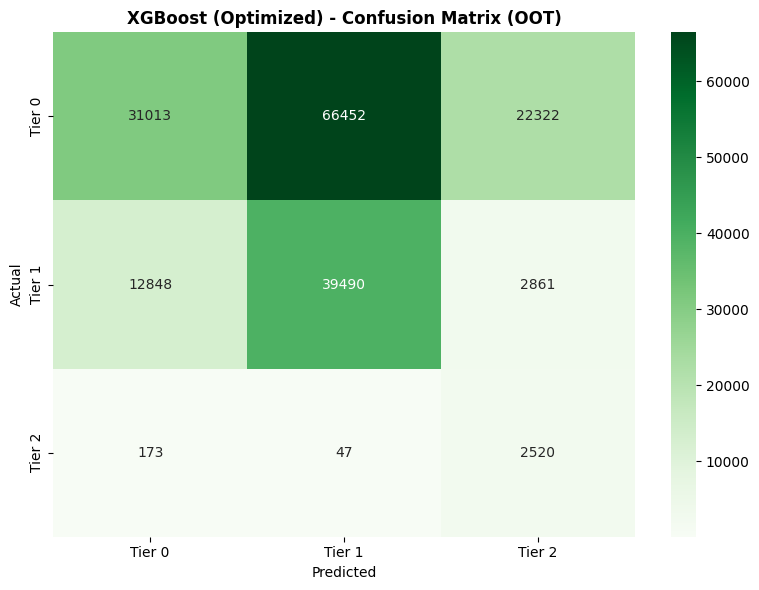

In [19]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_optimized = confusion_matrix(y_oot, y_pred_oot)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Tier 0', 'Tier 1', 'Tier 2'],
            yticklabels=['Tier 0', 'Tier 1', 'Tier 2'])
ax.set_title(f'{best_model_name} (Optimized) - Confusion Matrix (OOT)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('outputs/optimized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


FEATURE IMPORTANCE (Optimized)


           feature  importance
    dominant_topic    0.520096
     loyalty_score    0.173257
      churn_intent    0.097893
     sentiment_neu    0.035658
     urgency_score    0.032004
     sentiment_pos    0.031517
        word_count    0.029447
     sentiment_neg    0.028790
       text_length    0.028386
sentiment_compound    0.022952


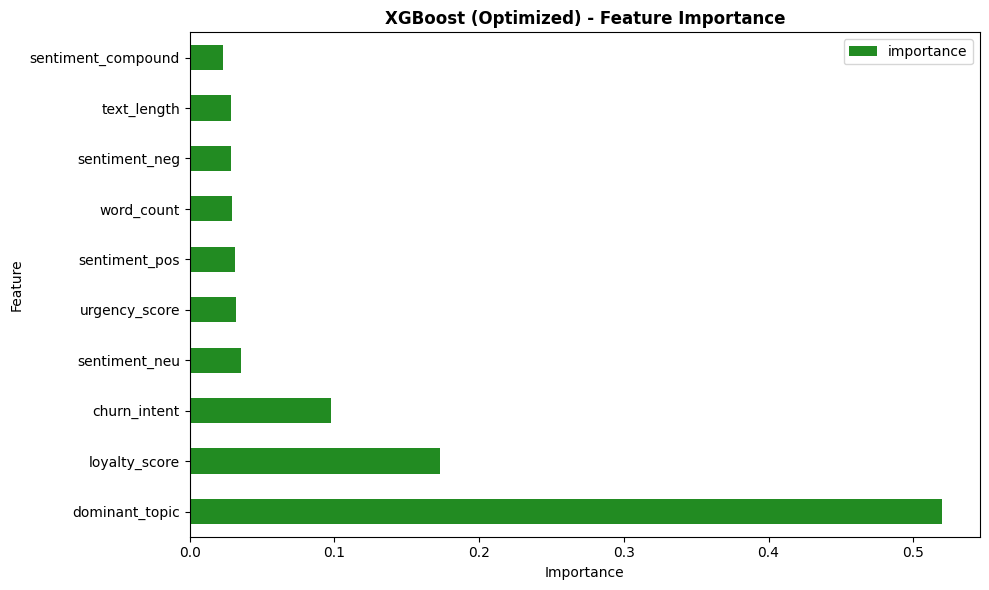

In [20]:
print("\n" + "="*80)
print("FEATURE IMPORTANCE (Optimized)")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': optimized_model.feature_importances_
}).sort_values('importance', ascending=False)
    
print("\n")
print(feature_importance.to_string(index=False))
    
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='feature', y='importance', kind='barh', ax=ax, color='forestgreen')
ax.set_title(f'{best_model_name} (Optimized) - Feature Importance', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/optimized_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
optimized_dict = {
    'model': optimized_model,
    'model_name': best_model_name,
    'best_params': grid_search.best_params_,
    'cv_score': grid_search.best_score_,
    'oot_auc': auc_ovo_oot,
    'feature_cols': feature_cols
}

with open('models/optimized_model.pkl', 'wb') as f:
    pickle.dump(optimized_dict, f)

print("\nOptimized model saved to models/optimized_model.pkl")

performance_comparison = pd.DataFrame({
    'Model': ['Baseline', 'Optimized'],
    'OOS_AUC': [baseline_performance['oos_auc'], grid_search.best_score_],
    'OOT_AUC': [baseline_performance['oot_auc'], auc_ovo_oot]
})

performance_comparison.to_csv('outputs/optimization_comparison.csv', index=False)
print("Performance comparison saved to outputs/optimization_comparison.csv")


Optimized model saved to models/optimized_model.pkl
Performance comparison saved to outputs/optimization_comparison.csv


In [22]:
optimized_performance = {
    'model': best_model_name,
    'best_params': grid_search.best_params_,
    'cv_score': float(grid_search.best_score_),
    'oot_auc': float(auc_ovo_oot),
    'improvement_over_baseline': float(auc_ovo_oot - baseline_performance['oot_auc'])
}

with open('outputs/optimized_performance.json', 'w') as f:
    json.dump(optimized_performance, f, indent=2)

print("Optimized performance saved to outputs/optimized_performance.json")

Optimized performance saved to outputs/optimized_performance.json
